# Проект:  Анализ продаж маркетплейса Olist
## Цель: определить ключевые драйверы выручки, выявить прибыльные категории и сегменты клиентов, чтобы сформулировать рекомендации по росту продаж.


# Этапы работы
## 1. Исследование данных и очистка
## 2. Анализ клиентов и сегментация 
## 3. Анализ динамики продаж и сезонности
## 4. Анализ категорий товаров 
## 5. Анализ эффективности продавцов

In [5]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [6]:
import os
os.getcwd()


'C:\\Users\\user\\analytics_practice\\olist-sales-analysis\\notebooks'

In [7]:
import pandas as pd
import matplotlib.pyplot as plt


## 1. Исследование и очистка (Data Exploration & Cleaning) 

In [8]:
customers=pd.read_csv('C:\\Users\\user\\analytics_practice\\olist-sales-analysis\\data\\olist_customers_dataset.csv', sep=',')

In [9]:
orders=pd.read_csv('C:\\Users\\user\\analytics_practice\\olist-sales-analysis\\data\\olist_orders_dataset.csv',sep=',')

In [10]:
order_items=pd.read_csv('C:\\Users\\user\\analytics_practice\\olist-sales-analysis\\data\\olist_order_items_dataset.csv',sep=',')

In [11]:
print("Пропуски в customers:")
print(customers.isna().sum())
print("Пропуски в orders:")
print(orders.isna().sum())
print("Пропуски в order_items:")
print(order_items.isna().sum())


Пропуски в customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Пропуски в orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Пропуски в order_items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [12]:
customers.duplicated().sum()
orders.duplicated().sum()
order_items.duplicated().sum()

np.int64(0)

np.int64(0)

np.int64(0)

## Вывод исследования данных: 
- таблицы не содержат пропущенных значений и дубликатов.
- поля цен и идентификаторов готовы к агрегации.

# 2. Анализ клиентов и сегментация, отфильтрованы исполненые заказы.
##  Бизнес-цель: Анализ клиентов по ценности. Кто приносит компании больше всего выручки и как распределяются клиенты по ценности?


# Customer analysis and segmentation.For revenue analysis, only paid and completed orders are considered.
## Customer Value Analysis: Who generates the most revenue for the company, and how are customers distributed by value?

In [13]:
customers_orders=customers.merge(orders,on='customer_id',how='left')

In [14]:
customers_orders_full=customers_orders.merge(order_items, on='order_id',how='left')

In [15]:
# Фильтруем с созданием копии
orders_delivered = customers_orders_full[customers_orders_full['order_status'] == 'delivered'].copy()

# Считаем полную сумму для каждой позиции (товар + доставка)
orders_delivered['total_sum'] = orders_delivered['price'] + orders_delivered['freight_value']


## Какие клиенты формируют наивысшую выручку ТОР-10 
## Which customers generate the highest revenue

In [16]:
# 1. Группируем по уникальному ID клиента и суммируем выручку
customer_value = orders_delivered.groupby('customer_unique_id')['total_sum'].sum().reset_index()

# 2. Сортируем по убыванию выручки (самые крупные — сверху)
customer_value = customer_value.sort_values(by='total_sum', ascending=False)

# 3. Переименовываем столбцы 
customer_value.columns = ['Customer Unique ID', 'Total Revenue']

# 4. Выводим топ-10
customer_value.head(10)

,Customer Unique ID,Total Revenue
3724,0a0a92112bd4c708ca5fde585afaa872,13664.08
79636,da122df9eeddfedc1dc1f5349a1a690c,7571.63
43168,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
80463,dc4802a71eae9be1dd28f5d788ceb526,6929.31
25436,459bef486812aa25204be022145caa62,6922.21
93081,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
23411,4007669dec559734d6f53e029e360987,6081.54
87148,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34
26640,48e1ac109decbb87765a3eade6854098,4681.78
73127,c8460e4251689ba205045f3ea17884a1,4655.88


## Классификация клиентов по их ценности для компании на основе общей суммы затрат
## Classification of customers based on their value to the company, based on the total amount of costs

In [17]:
# Создаем сегменты
customer_value['Segment'] = pd.qcut(customer_value['Total Revenue'], 
                                    q=[0, 0.80, 0.95, 1], 
                                    labels=['Regular', 'Silver', 'Gold'])


In [18]:
# 1. Группируем по сегментам и считаем общую выручку и количество клиентов
segment_analysis = customer_value.groupby('Segment',observed=False).agg({
    'Customer Unique ID': 'count',
    'Total Revenue': 'sum'
}).rename(columns={'Customer Unique ID': 'Customer Count'})



In [19]:
# 2. Считаем долю выручки в процентах
total_revenue_sum = segment_analysis['Total Revenue'].sum()
segment_analysis['Revenue %'] = (segment_analysis['Total Revenue'] / total_revenue_sum * 100).round(2)

In [20]:
# 3. Сортируем для наглядности (от VIP к Regular)
segment_analysis = segment_analysis.sort_values(by='Total Revenue', ascending=False)

print(segment_analysis)

         Customer Count  Total Revenue  Revenue %
Segment                                          
Regular           74686     7166224.14      46.47
Gold               4668     4132066.26      26.80
Silver            14004     4121483.35      26.73


In [21]:
# Считаем общее количество клиентов
total_customers_count = segment_analysis['Customer Count'].sum()

# Добавляем колонку с процентом клиентов
segment_analysis['Customer %'] = (segment_analysis['Customer Count'] / total_customers_count * 100).round(2)

# Выводим итоговую таблицу
print(segment_analysis)

         Customer Count  Total Revenue  Revenue %  Customer %
Segment                                                      
Regular           74686     7166224.14      46.47        80.0
Gold               4668     4132066.26      26.80         5.0
Silver            14004     4121483.35      26.73        15.0


# Сегментация клиентской базы по выручке (Monetary Analysis)
## Аналитические выводы:
    1. Концентрация выручки: 20% наиболее ценных клиентов (сегменты Gold и Silver) формируют 53,5% общей выручки. Наблюдается высокая концентрация дохода в верхних сегментах клиентской базы.
    2. Эффективность VIP-сегмента: Сегмент Gold составляет 5% от общего числа клиентов, но генерирует 26,8% выручки. Средний доход на одного клиента Gold почти в 6 раз превышает показатель массового сегмента.
    3. Структура вклада: Сегмент Regular (80% клиентской базы) обеспечивает 46,5% выручки. Это свидетельствует о широкой вовлеченности аудитории, но также указывает на зависимость бизнеса от объёма транзакций массового сегмента.
## Бизнес-рекомендации:
    •  Разработать программу удержания для сегмента Gold.
    •  Проанализировать барьеры перехода клиентов из Silver в Gold.
    •  Повысить персонализацию маркетинговых коммуникаций.
# Customer Revenue Segmentation (Monetary Analysis)
## Analytical Insights:
    1. Revenue Concentration: The top 20% of customers (Gold and Silver segments combined) generate 53.5% of total revenue, indicating a high concentration of income within the upper customer tiers.
    2. VIP Segment Efficiency: The Gold segment represents only 5% of the total customer base but contributes 26.8% of overall revenue. On average, a Gold customer generates nearly six times more revenue than a Regular customer.
    3. Revenue Structure: The Regular segment (80% of customers) accounts for 46.5% of total revenue. This reflects broad market reach while also highlighting reliance on high-volume transactional activity from the mass segment.
## Business Recommendations:
    •  Implement a retention-focused loyalty program for the Gold segment.
    •  Analyze conversion barriers preventing Silver customers from moving into Gold.
    •  Enhance personalization strategies to increase customer lifetime value.


# 3. Анализ динамики продаж и сезонности
## Бизнес-цель: Выявить периоды максимальной активности покупателей и оценить темпы роста выручки от месяца к месяцу.
# Sales Dynamics and Seasonality Analysis 
## Identify periods of peak customer activity and evaluate revenue growth rates from month to month.

In [22]:
orders_delivered['order_purchase_timestamp']=pd.to_datetime(orders_delivered['order_purchase_timestamp'])
orders_delivered['order_purchase_month']=orders_delivered['order_purchase_timestamp'].dt.month
orders_delivered['order_purchase_year']=orders_delivered['order_purchase_timestamp'].dt.year

In [23]:
# 1. Группируем сразу и количество (count), и сумму (sum)
sales_dynamic = orders_delivered.groupby(['order_purchase_year', 'order_purchase_month']).agg({
    'order_id': 'count',
    'total_sum': 'sum'
}).reset_index()

# 2. Переименовываем колонки 
sales_dynamic.columns = ['year', 'month', 'order_count', 'revenue']

# 3. Создаем единую колонку даты
sales_dynamic['date'] = pd.to_datetime(sales_dynamic['year'].astype(str) + '-' + 
                                       sales_dynamic['month'].astype(str) + '-01')

# 4. Сортируем хронологически
sales_dynamic = sales_dynamic.sort_values('date')

In [24]:
# Рассчитываем средний чек (AOV - Average Order Value)
sales_dynamic['average_check'] = (sales_dynamic['revenue'] / sales_dynamic['order_count']).round(2)

<Axes: xlabel='date', ylabel='revenue'>

Text(0, 0.5, 'Выручка (R$)')

<Axes: xlabel='date', ylabel='order_count'>

Text(0, 0.5, 'Объем заказов')

Text(0.5, 1.0, 'Ежемесячные показатели продаж: Соотношение выручки и объема заказов')

Text(0.5, 0, 'Дата')

(array([17075., 17167., 17257., 17348., 17440., 17532., 17622., 17713.]),
 [Text(17075.0, 0, '2016-10'),
  Text(17167.0, 0, '2017-01'),
  Text(17257.0, 0, '2017-04'),
  Text(17348.0, 0, '2017-07'),
  Text(17440.0, 0, '2017-10'),
  Text(17532.0, 0, '2018-01'),
  Text(17622.0, 0, '2018-04'),
  Text(17713.0, 0, '2018-07')])

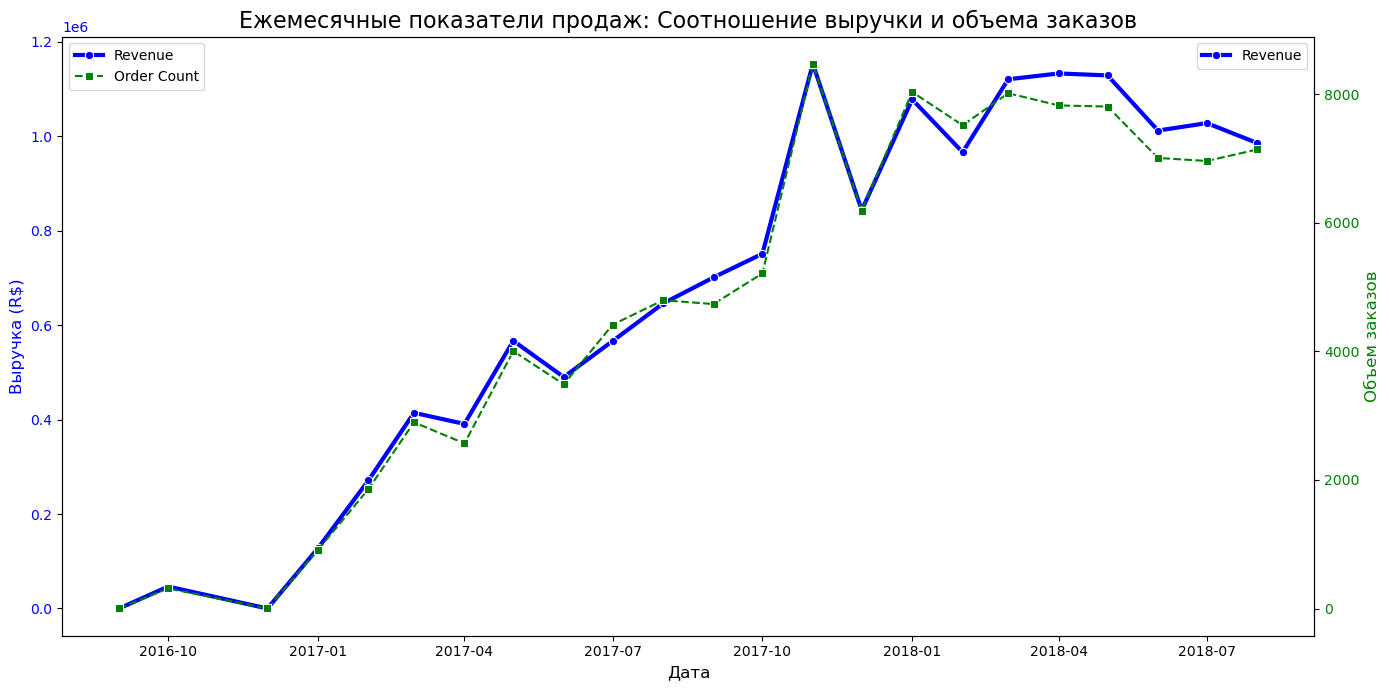

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(14, 7))

# График выручки (Линия)
sns.lineplot(data=sales_dynamic, x='date', y='revenue', ax=ax1, color='b', marker='o', linewidth=3, label='Revenue')
ax1.set_ylabel('Выручка (R$)', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')

# Создаем вторую ось для количества заказов
ax2 = ax1.twinx()
sns.lineplot(data=sales_dynamic, x='date', y='order_count', ax=ax2, color='g', marker='s', linestyle='--', label='Order Count')
ax2.set_ylabel('Объем заказов', color='g', fontsize=12)
ax2.tick_params(axis='y', labelcolor='g')

plt.title('Ежемесячные показатели продаж: Соотношение выручки и объема заказов', fontsize=16)
ax1.set_xlabel('Дата', fontsize=12)
plt.xticks(rotation=45)

# Объединяем легенды
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

<Figure size 1400x500 with 0 Axes>

<Axes: xlabel='date', ylabel='average_check'>

Text(0.5, 1.0, 'Динамика среднего чека по месяцам (Average Order Value)')

Text(0, 0.5, 'Средний чек (R$)')

Text(0.5, 0, 'Дата')

(array([17075., 17167., 17257., 17348., 17440., 17532., 17622., 17713.]),
 [Text(17075.0, 0, '2016-10'),
  Text(17167.0, 0, '2017-01'),
  Text(17257.0, 0, '2017-04'),
  Text(17348.0, 0, '2017-07'),
  Text(17440.0, 0, '2017-10'),
  Text(17532.0, 0, '2018-01'),
  Text(17622.0, 0, '2018-04'),
  Text(17713.0, 0, '2018-07')])

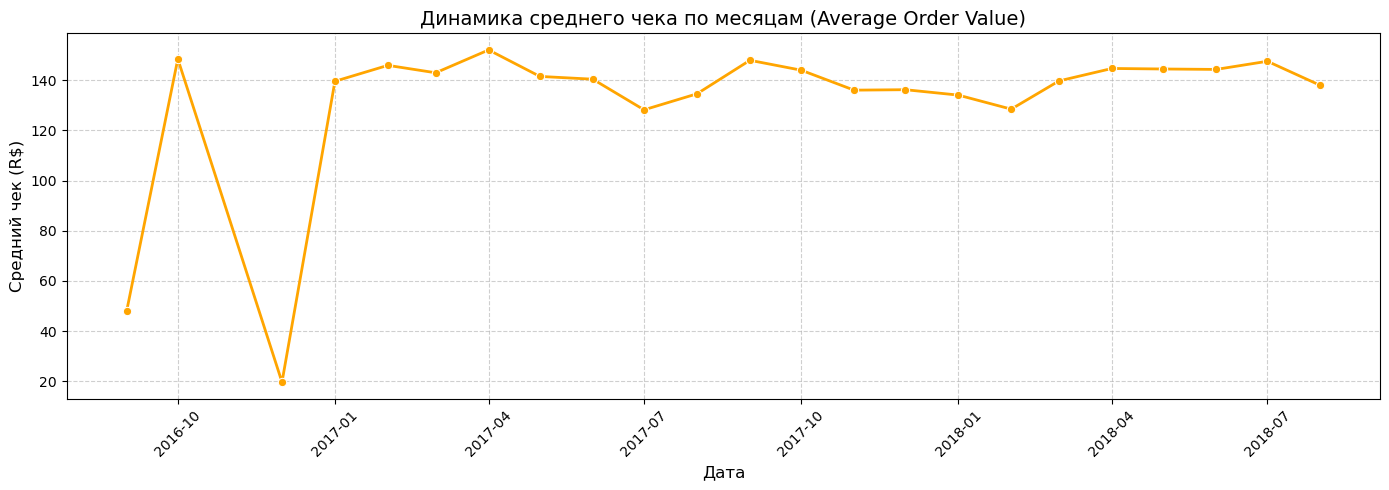

In [26]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=sales_dynamic, x='date', y='average_check', marker='o', color='orange', linewidth=2)

plt.title('Динамика среднего чека по месяцам (Average Order Value)', fontsize=14)
plt.ylabel('Средний чек (R$)', fontsize=12)
plt.xlabel('Дата', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Аналитические выводы:
    1. Устойчивый рост: С января 2017 по август 2018 наблюдается выраженный восходящий тренд по выручке и количеству заказов. К середине 2018 года месячная выручка выросла более чем в 5 раз относительно начала периода.
    2. Сезонный фактор (Black Friday): В ноябре 2017 года зафиксирован абсолютный пик продаж. Рост обусловлен увеличением количества заказов при одновременном снижении среднего чека, что свидетельствует о массовом характере покупок.
    3. Стабильность среднего чека: Средний чек после периода распродаж остается относительно стабильным (≈ $140), что указывает на количественную природу роста, а не изменение ценовой стратегии.
## Бизнес-рекомендации:
    •  Планировать расширение логистических мощностей в IV квартале.
    •  Проанализировать факторы роста среднего чека в октябре 2016 года.
    •  Усилить подготовку к сезонным пиковым нагрузкам.
## Analytical Insights:
    1. Sustained Growth Trend: From January 2017 to August 2018, both revenue and order volume show a strong upward trajectory. Monthly revenue by mid-2018 increased more than fivefold compared to early 2017, indicating rapid business scaling.
    2. Seasonal Impact (Black Friday): A significant sales peak was observed in November 2017. Growth was primarily driven by increased order volume, while Average Order Value (AOV) slightly decreased, suggesting mass-purchase behavior during promotional campaigns.
    3. AOV Stability: Post-promotional AOV remained relatively stable (approximately $140), confirming that revenue growth was driven mainly by customer acquisition and order volume rather than pricing changes.
## Business Recommendations:
    •  Scale logistics and warehouse capacity in Q4 to handle seasonal demand spikes.
    •  Investigate the drivers behind the temporary AOV increase in October 2016.
    •  Strengthen operational readiness ahead of peak promotional periods.


# 4. Анализ категорий товаров по вкладу в выручку
# Product Category Revenue Analysis
## Бизнес-цель: Выявить ключевые драйверы прибыли и проследить изменение структуры спроса во времени.
## Analysis of product categories by their contribution to revenue as a whole and by periods.

In [27]:
product=pd.read_csv('C:\\Users\\user\\analytics_practice\\olist-sales-analysis\\data\\olist_products_dataset.csv',sep=',')
product_name=pd.read_csv('C:\\Users\\user\\analytics_practice\\olist-sales-analysis\\data\\product_category_name_translation.csv',sep=',')

In [55]:
# Объединяем данные исключив непроданные товары
result = (
    product
    .merge(product_name, on='product_category_name', how='left')
    .merge(order_items, on='product_id', how='left')
    .merge(orders_delivered, on='order_id', how='left')
    .dropna(subset=['order_id']) # Оставляем только проданные товары
).rename(columns={'price_y': 'price'})



In [56]:
# Считаем вклад категорий в общую выручку
# Используем price, так как total_sum (с доставкой) привязана к заказу целиком, 
# а категории привязаны к конкретным товарам внутри заказа.

category_revenue = (
    result
    .groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
)
category_revenue.head()

product_category_name_english
bed_bath_table           1404030.33
health_beauty            1402446.97
computers_accessories    1333974.94
watches_gifts            1271438.12
sports_leisure           1142719.15
Name: price, dtype: float64

In [ ]:
# Группируем данные по английскому названию категории
# Используем [['price']], чтобы результат сразу был в формате DataFrame
category_revenue = (
    result
    .groupby('product_category_name_english')[['price']]
    .sum()
    .sort_values(by='price', ascending=False)
)

# 1. Рассчитываем суммарную выручку по всем категориям для вычисления доли
total_revenue_sum = category_revenue['price'].sum()

# 2. Добавляем колонку с долей каждой категории в общей выручке (%)
category_revenue['Contribution %'] = (category_revenue['price'] / total_revenue_sum * 100).round(2)

# 3. Переименовываем колонку 'price' в 'Revenue (R$)' для финального отчета
category_analysis = category_revenue.rename(columns={'price': 'Revenue (R$)'})

# Выводим Топ-10 категорий
print("Топ-10 категорий по вкладу в выручку:")
print(category_analysis.head(10))




In [ ]:
# Так как 'product_category_name_english' — это индекс, обращаемся к нему напрямую
top_5_category_names = category_analysis.index[:5].tolist()


In [ ]:
top_5_category=result[result['product_category_name_english'].isin(top_5_category_names)]

In [ ]:
# --- АНАЛИЗ ПО ПЕРИОДАМ ДЛЯ ТОП-5 КАТЕГОРИЙ ---

# 1. Создаем колонку периода (Год-Месяц)
# Используем .to_period('M'), чтобы получить удобный формат для группировки
top_5_category['month_period'] = top_5_category['order_purchase_timestamp'].dt.to_period('M')

# 2. Создаем сводную таблицу (Pivot Table)
# Индексом будет месяц, колонками — названия категорий, значениями — сумма цен
pivot_revenue = top_5_category.pivot_table(
    index='month_period', 
    columns='product_category_name_english', 
    values='price', 
    aggfunc='sum'
)

# 3. Визуализация динамики
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
pivot_revenue.plot(kind='line', marker='o', ax=plt.gca())

plt.title('Динамика выручки ТОП-5 категорий по месяцам', fontsize=16)
plt.xlabel('Период (Месяц)', fontsize=12)
plt.ylabel('Выручка (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Категории', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Выведем последние месяцы для проверки
print("Последние данные сводной таблицы (выручка по месяцам):")
print(pivot_revenue.tail())

## Аналитические выводы
    1. Основная выручка сосредоточена в нескольких категориях.Лидерами являются health_beauty и watches_gifts.
    2. Стабильные драйверы продаж: Категории bed_bath_table и computers_accessories демонстрируют устойчивый вклад в оборот.
    3. Сбалансированная структура. Нет критической зависимости от одной категории — ассортимент диверсифицирован.
    4. Выраженная сезонность. В ноябре 2017 года наблюдается резкий рост продаж (Black Friday).
    5. Разная динамика категорий. health_beauty показывает стабильный рост, watches_gifts — более выраженные сезонные колебания.
## Бизнес-рекомендации
    •  Развивать и продвигать наиболее прибыльные категории.
    •  Инвестировать в стабильные сегменты как основу долгосрочного роста.
    •  Поддерживать диверсификацию ассортимента для снижения рисков.
    •  Усиливать подготовку к сезонным пикам продаж.
    •  Улучшать прогнозирование спроса для сезонных категорий.
    •  Использовать кросс-продажи для увеличения среднего чека.
## Analytical Insights
    1. Revenue is concentrated in several key categories. The leaders are health_beauty and watches_gifts.
    2. Stable growth drivers: bed_bath_table and computers_accessories show consistent contribution to total revenue.
    3. Balanced structure.No critical dependency on a single category — the portfolio is diversified.
    4. Strong seasonality. A significant sales spike occurred in November 2017 (Black Friday).
    5. Different growth patterns. health_beauty demonstrates stable growth, while watches_gifts shows higher seasonal volatility.
## Business Recommendations
    •  Strengthen and promote high-performing categories.
    •  Invest in stable segments as long-term growth drivers.
    •  Maintain portfolio diversification to reduce risk.
    •  Improve readiness for seasonal sales peaks.
    •  Enhance demand forecasting for seasonal categories.
    •  Use cross-selling strategies to increase AOV.


# 4. Анализ эффиктивности продавцов
## Ранжирование ТОП-5 лидеров по объему выручки и анализ их влияния на общий оборот маркетплейса.

# Analysis of sales force performance
## Identifying the Top 5 Sellers by Revenue and Assessing Their Contribution to Total GMV (Gross Merchandise Volume)

In [ ]:
sellers = pd.read_csv('C:\\Users\\user\\analytics_practice\\olist-sales-analysis\\data\\olist_sellers_dataset.csv')
result_sellers=result.merge(sellers,left_on='seller_id_y',right_on='seller_id',how='left')
sellers_top_5=result_sellers.groupby(['seller_id','seller_city'])['price'].sum().sort_values(ascending=False).reset_index().head(5)
sellers_top_5['revenue_share_%']=(sellers_top_5['price']/total_revenue_sum * 100).round(2)

print("ТОП-5 Продавцов по выручке:")
print(sellers_top_5)
# 3. Агрегация выручки по продавцам
seller_revenue = (
    result_sellers
    .groupby(['seller_id', 'seller_city'])['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# 4. РАСЧЕТ КВАНТИЛЕЙ (Статистический профиль)
# Определяем границы для разных групп
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99]
revenue_thresholds = seller_revenue['price'].quantile(quantiles)

print("СТАТИСТИЧЕСКИЕ ПОРОГИ ВЫРУЧКИ (Квантили):")
for q, val in zip(quantiles, revenue_thresholds):
    print(f"Топ-{int((1-q)*100)}% продавцов имеют выручку более: R$ {val:,.2f}")

# 5. СЕГМЕНТАЦИЯ ПРОДАВЦОВ
def classify_seller(rev):
    if rev >= revenue_thresholds[0.99]: return '1. Elite (Top 1%)'
    elif rev >= revenue_thresholds[0.9]: return '2. Major (Top 10%)'
    elif rev >= revenue_thresholds[0.5]: return '3. Mid-sized (Top 50%)'
    else: return '4. Small/Tail'

seller_revenue['seller_segment'] = seller_revenue['price'].apply(classify_seller)

# 6. АНАЛИЗ КОНЦЕНТРАЦИИ ВЫРУЧКИ
segment_analysis = (
    seller_revenue
    .groupby('seller_segment')
    .agg(
        num_sellers=('seller_id', 'count'),
        total_segment_revenue=('price', 'sum')
    )
    .reset_index()
)

# Считаем долю сегмента в общей выручке
total_rev = seller_revenue['price'].sum()
segment_analysis['revenue_share_%'] = (segment_analysis['total_segment_revenue'] / total_rev * 100).round(2)

print("\nАНАЛИЗ КОНЦЕНТРАЦИИ РЫНКА ПО СЕГМЕНТАМ:")
print(segment_analysis)

# 7. ВЫВОД ТОП-5 ДЛЯ ПОРТФОЛИО (с указанием сегмента)
print("\nДЕТАЛЬНЫЙ АНАЛИЗ ТОП-5 ПРОДАВЦОВ:")
top_5 = seller_revenue.head(5).copy()
top_5['times_better_than_median'] = (top_5['price'] / seller_revenue['price'].median()).round(1)
print(top_5[['seller_id', 'seller_city', 'price', 'seller_segment', 'times_better_than_median']])


In [ ]:
sellers_top_5.info()
segment_analysis.info()
segment_analysis.head()

In [ ]:
# =================================================================
# ЧАСТЬ 3: ВИЗУАЛИЗАЦИЯ КОНЦЕНТРАЦИИ И ДИНАМИКИ
# =================================================================

plt.style.use('seaborn-v0_8-muted')
fig = plt.figure(figsize=(18, 12))

# --- ГРАФИК 1: Концентрация рынка (Бар-чарт с двойной осью) ---
ax1 = plt.subplot(2, 2, 1)

sns.barplot(data=segment_analysis, x='seller_segment', y='num_sellers', ax=ax1, color='skyblue', alpha=0.7)
ax1.set_title('Количество продавцов по сегментам', fontsize=14)
ax1.set_ylabel('Кол-во продавцов', color='blue')

# Вторая ось для выручки
ax1_rev = ax1.twinx()
sns.lineplot(data=segment_analysis, x='seller_segment', y='total_segment_revenue', ax=ax1_rev, color='red', marker='o', linewidth=3)
ax1_rev.set_ylabel('Суммарная выручка (R$)', color='red')

# --- ГРАФИК 2: Доля сегментов в пироге ---
ax2 = plt.subplot(2, 2, 2)
ax2.pie(segment_analysis['total_segment_revenue'], labels=segment_analysis['seller_segment'], autopct='%1.1f%%', startangle=140)
ax2.set_title('Доля выручки в общем обороте', fontsize=14)

## Аналитические выводы:
    1. Принцип Парето: Сегменты Elite и Major (10% продавцов) обеспечивают 47,6% выручки, что подтверждает высокую концентрацию оборота в узком ядре селлеров.
    2. Операционная нагрузка: Сегмент Small/Tail отличается высокой фрагментацией, создавая дополнительную нагрузку на операционные процессы.
    3. Стабильность и волатильность: Сегменты Elite и Mid-sized демонстрируют устойчивый тренд, тогда как Major характеризуется большей чувствительностью к краткосрочным факторам.
## Бизнес-рекомендации:
    •  Разработать программу развития Mid-sized продавцов.
    •  Снизить зависимость от узкого круга Elite-селлеров.
    •  Повысить маркетинговую гибкость для сегмента Small/Tail.
## Analytical Insights:
    1. Pareto Effect:Elite and Major sellers (10% of total sellers) generate 47.6% of total revenue, confirming strong revenue concentration within a limited seller core.
    2. Operational Fragmentation: The Small/Tail segment shows high fragmentation, increasing operational complexity and support costs.
    3. Stability vs. Volatility: Elite and Mid-sized sellers demonstrate more stable performance trends, while the Major segment shows higher short-term fluctuations, indicating greater sensitivity to promotional cycles.
## Business Recommendations:
    •  Develop an acceleration program for Mid-sized sellers to strengthen the middle segment.
    •  Reduce strategic dependence on a narrow group of Elite sellers.
    •  Improve marketing flexibility and support for Small/Tail sellers to enhance performance consistency.



## Анализ динамики выручки продавцов по сегментам( с фиксацией сегмента).
## Analyze the revenue dynamics of sellers by segment (with segment fixation).

In [ ]:
# =================================================================
# 1. ПОДГОТОВКА И СЕГМЕНТАЦИЯ
# =================================================================

# Считаем общую выручку по каждому продавцу для определения его "веса"
result_sellers_total = result_sellers.groupby('seller_id')['price'].sum().reset_index()

# ЛОГИЧЕСКИЙ НЮАНС qcut:
# qcut (Quantile-based discretization) делит выборку на группы, в которых 
# ОДИНАКОВОЕ КОЛИЧЕСТВО объектов (продавцов). 
# Например, q=0.5 (медиана) гарантирует, что 50% продавцов попадут в нижнюю группу.
# Это "верно", если ваша цель — сравнить группы равного размера.
# Но если вы хотите выделить тех, кто принес ровно > 100 000 R$, 
# лучше использовать pd.cut, так как границы qcut зависят от распределения данных.

result_sellers_total['Segment'] = pd.qcut(
    result_sellers_total['price'], 
    q=[0, 0.5, 0.9, 0.99, 1], 
    labels=['Small/Tail', 'Mid-sized', 'Major', 'Elite']
)

# Объединяем сегмент с основной таблицей (исправляем опечатку в seller_id)
result_sellers_full = result_sellers.merge(
    result_sellers_total[['seller_id', 'Segment']], 
    on='seller_id', 
    how='left'
)

# Создаем периоды (исправляем .dt)
result_sellers_full['period'] = result_sellers_full['order_purchase_timestamp'].dt.to_period('M')




In [ ]:
# =================================================================
# 2. ФИНАЛЬНАЯ ГРУППИРОВКА ДЛЯ ВИЗУАЛИЗАЦИИ
# =================================================================

# Считаем выручку по периодам и сегментам
result_sellers_finish = (
    result_sellers_full
    .groupby(['period', 'Segment'])['price']
    .sum()
    .reset_index()
)

# Переводим период в строку для корректного отображения на графике
result_sellers_finish['period_str'] = result_sellers_finish['period'].astype(str)


In [ ]:
# =================================================================
# 3. ВИЗУАЛИЗАЦИЯ
# =================================================================

plt.figure(figsize=(15, 7))
sns.lineplot(
    data=result_sellers_finish, 
    x='period_str', 
    y='price', 
    hue='Segment', 
    marker='o'
)

plt.title('Динамика выручки по сегментам продавцов (с фиксацией сегмента)', fontsize=15)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Аналитические выводы:
    1. Реакция на Black Friday: В ноябре 2017 года сегменты Elite, Major и Mid-sized продемонстрировали выраженный рост продаж, что подтверждает их высокую операционную готовность к пиковым нагрузкам.
    2. Инертность сегмента Small/Tail: Сегмент Small/Tail не показал значимой положительной динамики даже в периоды масштабных распродаж, что может свидетельствовать о низкой маркетинговой активности или ограниченных ресурсах.
    3. Стабильность и волатильность: Сегменты Elite и Mid-sized характеризуются более устойчивой динамикой продаж, тогда как Major демонстрирует повышенную волатильность и зависимость от краткосрочных сезонных факторов.
## Бизнес-рекомендации:
    •  Масштабировать поддержку сегментов Elite и Mid-sized в периоды пикового спроса, обеспечивая приоритетную логистику и маркетинговое продвижение.
    •  Разработать программы развития для сегмента Small/Tail с целью повышения их вовлеченности в сезонные акции.
    •  Снизить волатильность сегмента Major за счёт более стабильного маркетингового планирования и диверсификации источников продаж.
    •  Использовать пиковые периоды как инструмент привлечения новых продавцов в растущие сегменты.
## Analytical Insights:
    1. Black Friday Response: In November 2017, Elite, Major, and Mid-sized segments experienced a significant sales surge, confirming their strong operational readiness during peak demand periods.
    2. Small/Tail Segment Inertia: The Small/Tail segment showed no substantial growth even during major promotional events, suggesting limited marketing flexibility or constrained operational capacity.
    3. Stability vs. Volatility: Elite and Mid-sized segments demonstrate more stable sales trends, while the Major segment exhibits higher volatility and greater dependence on short-term seasonal factors, making it less predictable in the long term.
## Business Implications
    •  Prioritize operational and marketing support for Elite and Mid-sized sellers during peak demand periods.
    •  Introduce development programs for the Small/Tail segment to increase participation in seasonal campaigns.
    •  Reduce volatility in the Major segment through more consistent marketing planning and diversified sales channels.
    •  Use seasonal peaks as an opportunity to attract and onboard new sellers into high-performing segments.        